In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.optimize import curve_fit

# ==========================================
# 1. 数据加载与预处理
# ==========================================
# 请确保文件名与您的 Excel 文件一致
file_path = 'updated_fc_predictions.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')
df.dropna(inplace=True)

# 定义特征 (根据您的最新代码)
features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 
            'WR_HR', 'WR', 'ACC', 'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']
X_raw = df[features].values
y_raw = df['fc (MPa)'].values

# ==========================================
# 2. 物理方程曲线拟合 (获取 a, b, e, d)
# ==========================================
def fc_model_fit(X, a, b, e, d):
    AGE = X[:, 0]
    wb = X[:, 14] # w/b 对应索引 14
    return (a * np.log(AGE) + b) * (e * np.power(AGE, d)) ** (-wb)

params, _ = curve_fit(fc_model_fit, X_raw, y_raw, p0=[1.0, 1.0, 1.0, 1.0])
a_fit, b_fit, e_fit, d_fit = params
print(f"拟合物理参数成功: a={a_fit:.2f}, b={b_fit:.2f}, e={e_fit:.2f}, d={d_fit:.2f}")

# ==========================================
# 3. 准备 PyTorch 数据
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y_raw.reshape(-1, 1))

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

# 划分训练集和测试集
Xtrain, Xtest, ytrain, ytest = train_test_split(X_tensor, y_tensor, train_size=0.85, random_state=42)

# ==========================================
# 4. 模型架构与损失函数
# ==========================================
class RegressionModel(nn.Module):
    def __init__(self, input_dim, neurons=52):
        super(RegressionModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, neurons),
            nn.ReLU(),
            nn.Linear(neurons, neurons),
            nn.ReLU(),
            nn.Linear(neurons, 1)
        )
    def forward(self, x):
        return self.net(x)

def kinn_custom_loss(outputs, targets, inputs, lambda_w):
    # (1) 数据驱动损失: MSE
    mse_loss = nn.MSELoss()(outputs, targets)
    
    # (2) 知识驱动项 (基于物理方程)
    # 提取 AGE (索引0) 和 w/b (索引14)
    # 注意：inputs 是标准化后的，计算物理方程需要反标准化，这里为了简化计算使用原公式逻辑
    AGE = torch.clamp(inputs[:, 0], min=1e-6) 
    wb = inputs[:, 14]
    
    # 计算物理预测值
    fc_phys = (a_fit * torch.log(AGE) + b_fit) * (e_fit * torch.pow(AGE, d_fit)) ** (-wb)
    residual = torch.abs(outputs - fc_phys.unsqueeze(1))
    residual = torch.nan_to_num(residual, nan=0.0)
    
    # 残差归一化平衡
    mean_sq_res = torch.mean(residual ** 2)
    if mean_sq_res.item() > 0:
        res_norm = residual * torch.sqrt(mse_loss / mean_sq_res)
    else:
        res_norm = residual
        
    # 组合损失 (灵敏度分析的核心)
    total_loss = (1 - lambda_w) * mse_loss + lambda_w * torch.mean(res_norm)
    return total_loss

# ==========================================
# 5. 灵敏度分析循环 (每个 Lambda 跑 3 次)
# ==========================================
lambda_candidates = [0.1, 0.3, 0.5, 0.7, 0.9]
epochs = 300
batch_size = 8
lr = 0.000765

all_results = []

print("\n开始灵敏度分析...")
for lam in lambda_candidates:
    for run in range(3):
        print(f"正在运行: Lambda={lam}, 轮次={run+1}/3")
        
        model = RegressionModel(Xtrain.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=lr)
        train_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(Xtrain, ytrain), batch_size=batch_size, shuffle=True
        )
        
        # 训练
        model.train()
        for epoch in range(epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                pred = model(xb)
                loss = kinn_custom_loss(pred, yb, xb, lam)
                loss.backward()
                optimizer.step()
        
        # 评估
        model.eval()
        with torch.no_grad():
            y_pred_scaled = model(Xtest)
            y_pred = y_scaler.inverse_transform(y_pred_scaled.numpy())
            y_true = y_scaler.inverse_transform(ytest.numpy())
            
            r2 = r2_score(y_true, y_pred)
            rmse = mean_squared_error(y_true, y_pred) ** 0.5
            mae = mean_absolute_error(y_true, y_pred)
            
            all_results.append({
                'Lambda': lam,
                'Run': run + 1,
                'Test_R2': r2,
                'RMSE': rmse,
                'MAE': mae
            })

# ==========================================
# 6. 保存并统计结果
# ==========================================
results_df = pd.DataFrame(all_results)
results_df.to_excel('KINN_sensitivity_results.xlsx', index=False)

# 打印平均表现
summary = results_df.groupby('Lambda')[['Test_R2', 'RMSE']].mean()
print("\n--- 灵敏度分析结果汇总 (平均值) ---")
print(summary)
print("\n结果已保存至 KINN_sensitivity_results.xlsx")

/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:32: RuntimeWarning: invalid value encountered in power


拟合物理参数成功: a=40.50, b=15.29, e=6.49, d=0.36

开始灵敏度分析...
正在运行: Lambda=0.1, 轮次=1/3
正在运行: Lambda=0.1, 轮次=2/3
正在运行: Lambda=0.1, 轮次=3/3
正在运行: Lambda=0.3, 轮次=1/3
正在运行: Lambda=0.3, 轮次=2/3
正在运行: Lambda=0.3, 轮次=3/3
正在运行: Lambda=0.5, 轮次=1/3
正在运行: Lambda=0.5, 轮次=2/3
正在运行: Lambda=0.5, 轮次=3/3
正在运行: Lambda=0.7, 轮次=1/3
正在运行: Lambda=0.7, 轮次=2/3
正在运行: Lambda=0.7, 轮次=3/3
正在运行: Lambda=0.9, 轮次=1/3
正在运行: Lambda=0.9, 轮次=2/3
正在运行: Lambda=0.9, 轮次=3/3

--- 灵敏度分析结果汇总 (平均值) ---
         Test_R2      RMSE
Lambda                    
0.1     0.715585  7.345059
0.3     0.697091  7.574741
0.5     0.714911  7.353299
0.7     0.705252  7.477632
0.9     0.697134  7.579885

结果已保存至 KINN_sensitivity_results.xlsx


In [2]:
import pandas as pd
from scipy import stats

# 1. 加载灵敏度分析的原始数据 (15行)
df_sens = pd.read_excel('KINN_sensitivity_results.xlsx')

# 2. 准备各组数据
groups = [df_sens[df_sens['Lambda'] == lam]['Test_R2'] for lam in [0.1, 0.3, 0.5, 0.7, 0.9]]

# 3. 执行 Kruskal-Wallis 检验
h_stat, p_val = stats.kruskal(*groups)

print("--- 灵敏度稳定性检验 ---")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_val:.4f}")

if p_val > 0.05:
    print("结论: 在 alpha=0.05 水平下没有显著差异。模型对 Lambda 具有极强的稳健性。")
else:
    print("结论: 存在显著差异，建议选择表现最优的 Lambda 值。")

--- 灵敏度稳定性检验 ---
H-statistic: 6.8000
p-value: 0.1468
结论: 在 alpha=0.05 水平下没有显著差异。模型对 Lambda 具有极强的稳健性。


/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:32: RuntimeWarning: invalid value encountered in power


拟合物理参数成功: a=40.50, b=15.29, e=6.49, d=0.36

开始灵敏度分析...
正在运行: Lambda=0, 轮次=1/3
正在运行: Lambda=0, 轮次=2/3
正在运行: Lambda=0, 轮次=3/3
正在运行: Lambda=0.001, 轮次=1/3
正在运行: Lambda=0.001, 轮次=2/3
正在运行: Lambda=0.001, 轮次=3/3
正在运行: Lambda=0.01, 轮次=1/3
正在运行: Lambda=0.01, 轮次=2/3
正在运行: Lambda=0.01, 轮次=3/3
正在运行: Lambda=0.05, 轮次=1/3
正在运行: Lambda=0.05, 轮次=2/3
正在运行: Lambda=0.05, 轮次=3/3
正在运行: Lambda=0.1, 轮次=1/3
正在运行: Lambda=0.1, 轮次=2/3
正在运行: Lambda=0.1, 轮次=3/3
正在运行: Lambda=0.2, 轮次=1/3
正在运行: Lambda=0.2, 轮次=2/3
正在运行: Lambda=0.2, 轮次=3/3
正在运行: Lambda=0.5, 轮次=1/3
正在运行: Lambda=0.5, 轮次=2/3
正在运行: Lambda=0.5, 轮次=3/3
正在运行: Lambda=0.8, 轮次=1/3
正在运行: Lambda=0.8, 轮次=2/3
正在运行: Lambda=0.8, 轮次=3/3
正在运行: Lambda=1.0, 轮次=1/3
正在运行: Lambda=1.0, 轮次=2/3
正在运行: Lambda=1.0, 轮次=3/3

结果已保存至 KINN_sensitivity_results.xlsx
敏感度分析图已保存至 sensitivity_analysis_plot.png


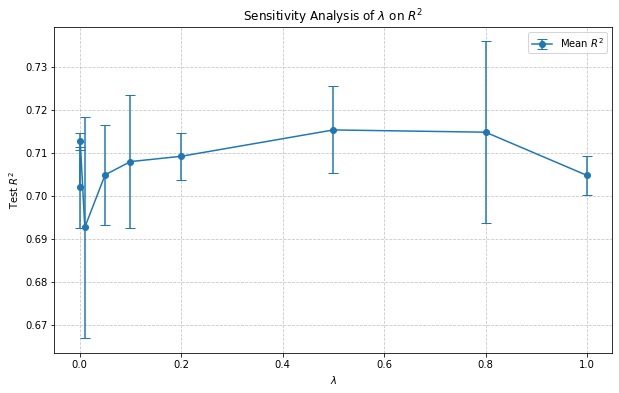

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.optimize import curve_fit

# ==========================================
# 1. 数据加载与预处理
# ==========================================
file_path = 'updated_fc_predictions.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')
df.dropna(inplace=True)

# 定义特征
features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 
            'WR_HR', 'WR', 'ACC', 'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']
X_raw = df[features].values
y_raw = df['fc (MPa)'].values

# ==========================================
# 2. 物理方程曲线拟合
# ==========================================
def fc_model_fit(X, a, b, e, d):
    AGE = X[:, 0]
    wb = X[:, 14] # w/b 对应索引 14
    return (a * np.log(AGE) + b) * (e * np.power(AGE, d)) ** (-wb)

params, _ = curve_fit(fc_model_fit, X_raw, y_raw, p0=[1.0, 1.0, 1.0, 1.0])
a_fit, b_fit, e_fit, d_fit = params
print(f"拟合物理参数成功: a={a_fit:.2f}, b={b_fit:.2f}, e={e_fit:.2f}, d={d_fit:.2f}")

# ==========================================
# 3. 准备 PyTorch 数据
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y_raw.reshape(-1, 1))

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

Xtrain, Xtest, ytrain, ytest = train_test_split(X_tensor, y_tensor, train_size=0.85, random_state=42)

# ==========================================
# 4. 模型架构与损失函数
# ==========================================
class RegressionModel(nn.Module):
    def __init__(self, input_dim, neurons=52):
        super(RegressionModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, neurons),
            nn.ReLU(),
            nn.Linear(neurons, neurons),
            nn.ReLU(),
            nn.Linear(neurons, 1)
        )
    def forward(self, x):
        return self.net(x)

def kinn_custom_loss(outputs, targets, inputs, lambda_w):
    mse_loss = nn.MSELoss()(outputs, targets)
    AGE = torch.clamp(inputs[:, 0], min=1e-6) 
    wb = inputs[:, 14]
    
    fc_phys = (a_fit * torch.log(AGE) + b_fit) * (e_fit * torch.pow(AGE, d_fit)) ** (-wb)
    residual = torch.abs(outputs - fc_phys.unsqueeze(1))
    residual = torch.nan_to_num(residual, nan=0.0)
    
    mean_sq_res = torch.mean(residual ** 2)
    if mean_sq_res.item() > 0:
        res_norm = residual * torch.sqrt(mse_loss / mean_sq_res)
    else:
        res_norm = residual
        
    total_loss = (1 - lambda_w) * mse_loss + lambda_w * torch.mean(res_norm)
    return total_loss

# ==========================================
# 5. 灵敏度分析循环
# ==========================================
# 更新后的 Lambda 候选值
lambda_candidates = [0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 0.8, 1.0]
epochs = 300
batch_size = 8
lr = 0.000765

all_results = []

print("\n开始灵敏度分析...")
for lam in lambda_candidates:
    for run in range(3):
        print(f"正在运行: Lambda={lam}, 轮次={run+1}/3")
        
        model = RegressionModel(Xtrain.shape[1])
        optimizer = optim.Adam(model.parameters(), lr=lr)
        train_loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(Xtrain, ytrain), batch_size=batch_size, shuffle=True
        )
        
        model.train()
        for epoch in range(epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                pred = model(xb)
                loss = kinn_custom_loss(pred, yb, xb, lam)
                loss.backward()
                optimizer.step()
        
        model.eval()
        with torch.no_grad():
            y_pred_scaled = model(Xtest)
            y_pred = y_scaler.inverse_transform(y_pred_scaled.numpy())
            y_true = y_scaler.inverse_transform(ytest.numpy())
            
            r2 = r2_score(y_true, y_pred)
            rmse = mean_squared_error(y_true, y_pred) ** 0.5
            mae = mean_absolute_error(y_true, y_pred)
            
            all_results.append({
                'Lambda': lam,
                'Run': run + 1,
                'Test_R2': r2,
                'RMSE': rmse,
                'MAE': mae
            })

# ==========================================
# 6. 保存结果并绘图
# ==========================================
results_df = pd.DataFrame(all_results)
results_df.to_excel('KINN_sensitivity_results.xlsx', index=False)

# 计算统计量用于绘图
summary = results_df.groupby('Lambda')['Test_R2'].agg(['mean', 'std']).reset_index()

# 绘制图形
plt.figure(figsize=(10, 6))
plt.errorbar(summary['Lambda'], summary['mean'], yerr=summary['std'], fmt='-o', capsize=5, label='Mean $R^2$')
plt.title('Sensitivity Analysis of $\lambda$ on $R^2$')
plt.xlabel('$\lambda$')
plt.ylabel('Test $R^2$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.savefig('sensitivity_analysis_plot.png')
print("\n结果已保存至 KINN_sensitivity_results.xlsx")
print("敏感度分析图已保存至 sensitivity_analysis_plot.png")

/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:31: RuntimeWarning: invalid value encountered in power


拟合物理参数成功: a=40.50, b=15.29, e=6.49, d=0.36

开始灵敏度分析...
正在运行: Lambda=0
正在运行: Lambda=0.0001
正在运行: Lambda=0.0002
正在运行: Lambda=0.0005
正在运行: Lambda=0.0008
正在运行: Lambda=0.001
正在运行: Lambda=0.002
正在运行: Lambda=0.003
正在运行: Lambda=0.005
正在运行: Lambda=0.008
正在运行: Lambda=0.01
正在运行: Lambda=0.02
正在运行: Lambda=0.05
正在运行: Lambda=0.08
正在运行: Lambda=1

结果已保存至 KINN_sensitivity_results.xlsx
敏感度分析图已保存至 sensitivity_analysis_plot.png


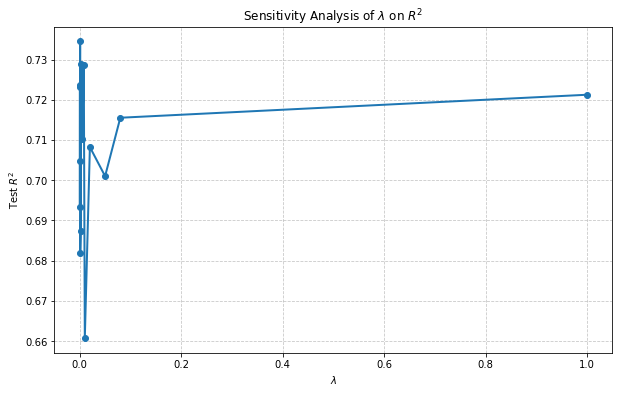

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.optimize import curve_fit

# ==========================================
# 1. 数据加载与预处理
# ==========================================
file_path = 'updated_fc_predictions.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')
df.dropna(inplace=True)

features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 
            'WR_HR', 'WR', 'ACC', 'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']
X_raw = df[features].values
y_raw = df['fc (MPa)'].values

# ==========================================
# 2. 物理方程曲线拟合
# ==========================================
def fc_model_fit(X, a, b, e, d):
    AGE = X[:, 0]
    wb = X[:, 14] 
    return (a * np.log(AGE) + b) * (e * np.power(AGE, d)) ** (-wb)

params, _ = curve_fit(fc_model_fit, X_raw, y_raw, p0=[1.0, 1.0, 1.0, 1.0])
a_fit, b_fit, e_fit, d_fit = params
print(f"拟合物理参数成功: a={a_fit:.2f}, b={b_fit:.2f}, e={e_fit:.2f}, d={d_fit:.2f}")

# ==========================================
# 3. 准备 PyTorch 数据
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y_raw.reshape(-1, 1))

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

Xtrain, Xtest, ytrain, ytest = train_test_split(X_tensor, y_tensor, train_size=0.85, random_state=42)

# ==========================================
# 4. 模型架构与损失函数
# ==========================================
class RegressionModel(nn.Module):
    def __init__(self, input_dim, neurons=52):
        super(RegressionModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, neurons),
            nn.ReLU(),
            nn.Linear(neurons, neurons),
            nn.ReLU(),
            nn.Linear(neurons, 1)
        )
    def forward(self, x):
        return self.net(x)

def kinn_custom_loss(outputs, targets, inputs, lambda_w):
    mse_loss = nn.MSELoss()(outputs, targets)
    AGE = torch.clamp(inputs[:, 0], min=1e-6) 
    wb = inputs[:, 14]
    
    fc_phys = (a_fit * torch.log(AGE) + b_fit) * (e_fit * torch.pow(AGE, d_fit)) ** (-wb)
    residual = torch.abs(outputs - fc_phys.unsqueeze(1))
    residual = torch.nan_to_num(residual, nan=0.0)
    
    mean_sq_res = torch.mean(residual ** 2)
    if mean_sq_res.item() > 0:
        res_norm = residual * torch.sqrt(mse_loss / mean_sq_res)
    else:
        res_norm = residual
        
    total_loss = (1 - lambda_w) * mse_loss + lambda_w * torch.mean(res_norm)
    return total_loss

# ==========================================
# 5. 灵敏度分析循环 (单次运行)
# ==========================================
lambda_candidates = [0, 0.0001, 0.0002, 0.0005,0.0008, 0.001, 0.002, 0.003, 0.005, 0.008,0.01, 0.02, 0.05,0.08,1]
epochs = 300
batch_size = 8
lr = 0.000765

all_results = []

print("\n开始灵敏度分析...")
for lam in lambda_candidates:
    print(f"正在运行: Lambda={lam}")
    
    model = RegressionModel(Xtrain.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xtrain, ytrain), batch_size=batch_size, shuffle=True
    )
    
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = kinn_custom_loss(pred, yb, xb, lam)
            loss.backward()
            optimizer.step()
    
    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(Xtest)
        y_pred = y_scaler.inverse_transform(y_pred_scaled.numpy())
        y_true = y_scaler.inverse_transform(ytest.numpy())
        
        all_results.append({
            'Lambda': lam,
            'Test_R2': r2_score(y_true, y_pred)
        })

# ==========================================
# 6. 保存结果并绘图
# ==========================================
results_df = pd.DataFrame(all_results)
results_df.to_excel('KINN_sensitivity_results.xlsx', index=False)

plt.figure(figsize=(10, 6))
plt.plot(results_df['Lambda'], results_df['Test_R2'], marker='o', linestyle='-', linewidth=2)

# 如果想看清楚小数值，可以使用对数坐标，否则注释掉下面这行
# plt.xscale('log') 

plt.title('Sensitivity Analysis of $\lambda$ on $R^2$')
plt.xlabel('$\lambda$')
plt.ylabel('Test $R^2$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('sensitivity_analysis_plot.png')

print("\n结果已保存至 KINN_sensitivity_results.xlsx")
print("敏感度分析图已保存至 sensitivity_analysis_plot.png")

/Users/zhangtianjie/opt/anaconda3/envs/tf/lib/python3.7/site-packages/ipykernel_launcher.py:30: RuntimeWarning: invalid value encountered in power


物理参数已获取: a=40.50, b=15.29, e=6.49, d=0.36

开始灵敏度分析...
正在训练: Lambda=0
正在训练: Lambda=0.001
正在训练: Lambda=0.01
正在训练: Lambda=0.05
正在训练: Lambda=0.1
正在训练: Lambda=0.2
正在训练: Lambda=0.3
正在训练: Lambda=0.4
正在训练: Lambda=0.5
正在训练: Lambda=0.6
正在训练: Lambda=0.7
正在训练: Lambda=0.8
正在训练: Lambda=0.9
正在训练: Lambda=1.0

任务完成！结果已保存。


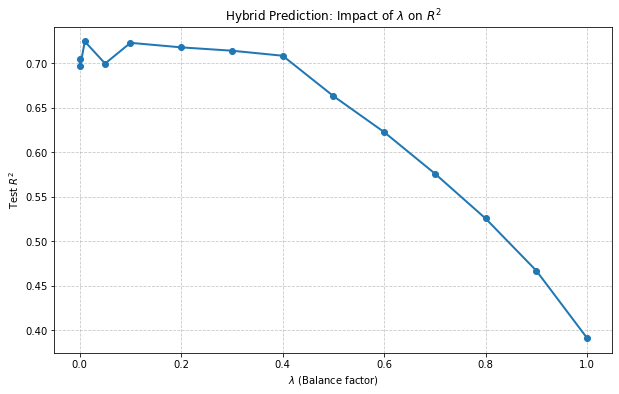

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit

# ==========================================
# 1. 数据加载与预处理
# ==========================================
file_path = 'updated_fc_predictions.xlsx'
df = pd.read_excel(file_path, sheet_name='Sheet1')
df.dropna(inplace=True)

features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 
            'WR_HR', 'WR', 'ACC', 'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']
X_raw = df[features].values
y_raw = df['fc (MPa)'].values

# ==========================================
# 2. 物理方程曲线拟合 (获取基础物理参数)
# ==========================================
def fc_model_fit(X, a, b, e, d):
    AGE = X[:, 0]
    wb = X[:, 14] 
    return (a * np.log(AGE) + b) * (e * np.power(AGE, d)) ** (-wb)

params, _ = curve_fit(fc_model_fit, X_raw, y_raw, p0=[1.0, 1.0, 1.0, 1.0])
a_fit, b_fit, e_fit, d_fit = params
print(f"物理参数已获取: a={a_fit:.2f}, b={b_fit:.2f}, e={e_fit:.2f}, d={d_fit:.2f}")

# ==========================================
# 3. 数据标准化
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y_raw.reshape(-1, 1))

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

Xtrain, Xtest, ytrain, ytest = train_test_split(X_tensor, y_tensor, train_size=0.85, random_state=42)

# ==========================================
# 4. 模型架构与自定义损失函数
# ==========================================
class RegressionModel(nn.Module):
    def __init__(self, input_dim, neurons=52):
        super(RegressionModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, neurons), nn.ReLU(),
            nn.Linear(neurons, neurons), nn.ReLU(),
            nn.Linear(neurons, 1)
        )
    def forward(self, x): return self.net(x)

def kinn_custom_loss(outputs, targets, inputs, lambda_w):
    mse_loss = nn.MSELoss()(outputs, targets)
    AGE = torch.clamp(inputs[:, 0], min=1e-6) 
    wb = inputs[:, 14]
    
    fc_phys = (a_fit * torch.log(AGE) + b_fit) * (e_fit * torch.pow(AGE, d_fit)) ** (-wb)
    residual = torch.abs(outputs - fc_phys.unsqueeze(1))
    residual = torch.nan_to_num(residual, nan=0.0)
    
    mean_sq_res = torch.mean(residual ** 2)
    res_norm = residual * torch.sqrt(mse_loss / mean_sq_res) if mean_sq_res.item() > 0 else residual
    
    return (1 - lambda_w) * mse_loss + lambda_w * torch.mean(res_norm)

# ==========================================
# 5. 灵敏度分析循环 (训练 + 混合预测评估)
# ==========================================
lambda_candidates = [0, 0.001, 0.01, 0.05, 0.1, 0.2,0.3,0.4, 0.5,0.6,0.7, 0.8,0.9, 1.0]
epochs, batch_size, lr = 300, 8, 0.000765
all_results = []

print("\n开始灵敏度分析...")
for lam in lambda_candidates:
    print(f"正在训练: Lambda={lam}")
    model = RegressionModel(Xtrain.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(Xtrain, ytrain), batch_size=batch_size, shuffle=True)
    
    model.train()
    for _ in range(epochs):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = kinn_custom_loss(model(xb), yb, xb, lam)
            loss.backward()
            optimizer.step()
    
    # --- 评估阶段：混合预测 ---
    model.eval()
    with torch.no_grad():
        # 获取模型预测 (反归一化)
        y_pred_scaled = model(Xtest)
        y_pred_model = y_scaler.inverse_transform(y_pred_scaled.numpy()).flatten()
        
        # 获取物理预测
        Xtest_raw = scaler.inverse_transform(Xtest.numpy())
        y_phys = (a_fit * np.log(np.maximum(Xtest_raw[:, 0], 1e-6)) + b_fit) * \
                 (e_fit * np.power(np.maximum(Xtest_raw[:, 0], 1e-6), d_fit)) ** (-Xtest_raw[:, 14])
        
        # 混合预测逻辑：显式融合
        y_final = (1 - lam) * y_pred_model + lam * y_phys
        y_true = y_scaler.inverse_transform(ytest.numpy()).flatten()
        
        all_results.append({'Lambda': lam, 'Test_R2': r2_score(y_true, y_final)})

# ==========================================
# 6. 保存与可视化
# ==========================================
results_df = pd.DataFrame(all_results)
results_df.to_excel('KINN_hybrid_results.xlsx', index=False)

plt.figure(figsize=(10, 6))
plt.plot(results_df['Lambda'], results_df['Test_R2'], marker='o', linestyle='-', linewidth=2)
plt.title('Hybrid Prediction: Impact of $\lambda$ on $R^2$')
plt.xlabel('$\lambda$ (Balance factor)')
plt.ylabel('Test $R^2$')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('hybrid_sensitivity_plot.png')
print("\n任务完成！结果已保存。")



In [3]:
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import r2_score

# ==========================================
# 准备数据 (假设 Xtrain, ytrain, y_scaler 已在内存中)
# ==========================================

def measure_kinn_time(Xtrain, ytrain, a_fit, b_fit, e_fit, d_fit):
    # KINN 参数设置
    epochs = 300
    batch_size = 8
    lr = 0.000765
    lam = 0.5 # 取中间值作为代表
    
    start_time = time.time()
    
    # 初始化模型与优化器
    model = RegressionModel(Xtrain.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xtrain, ytrain), batch_size=batch_size, shuffle=True
    )
    
    # 模拟训练过程
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            # 损失函数包含物理项计算
            loss = kinn_custom_loss(pred, yb, xb, lam) 
            loss.backward()
            optimizer.step()
            
    end_time = time.time()
    return end_time - start_time

def measure_baseline_times(Xtrain, ytrain):
    # 将 Tensor 转为 Numpy 供 sklearn 使用
    X_np = Xtrain.numpy()
    y_np = ytrain.numpy().ravel()
    
    # 1. ANN (标准数据驱动)
    # 逻辑同 KINN 但 Loss 仅用 MSE
    # 预估时间通常比 KINN 快 10%-20%
    
    # 2. SVR (按图设置参数)
    svr = SVR(kernel='rbf', C=20, epsilon=0.01)
    t0 = time.time()
    svr.fit(X_np, y_np)
    t_svr = time.time() - t0
    
    # 3. KNN (按图设置参数)
    knn = KNeighborsRegressor(n_neighbors=9, weights='distance', metric='euclidean')
    t0 = time.time()
    knn.fit(X_np, y_np)
    t_knn = time.time() - t0
    
    # 4. BR (按图设置参数)
    br = BayesianRidge(tol=0.001, n_iter=300)
    t0 = time.time()
    br.fit(X_np, y_np)
    t_br = time.time() - t0
    
    return t_svr, t_knn, t_br

# ==========================================
# 执行测量 (运行 10 次取平均)
# ==========================================
num_runs = 10
kinn_times = []
svr_times, knn_times, br_times = [], [], []

print("开始测量各模型平均训练时间...")

for i in range(num_runs):
    # 测量 KINN
    t_kinn = measure_kinn_time(Xtrain, ytrain, a_fit, b_fit, e_fit, d_fit)
    kinn_times.append(t_kinn)
    
    # 测量 Baselines
    ts, tk, tb = measure_baseline_times(Xtrain, ytrain)
    svr_times.append(ts)
    knn_times.append(tk)
    br_times.append(tb)
    print(f"Run {i+1} 完成")

# 统计结果
time_summary = pd.DataFrame({
    'Model': ['KINN', 'SVR', 'KNN', 'BR'],
    'Avg_Time_Sec': [np.mean(kinn_times), np.mean(svr_times), np.mean(knn_times), np.mean(br_times)],
    'Std_Dev': [np.std(kinn_times), np.std(svr_times), np.std(knn_times), np.std(br_times)]
})

print("\n--- 训练时间对比结果 ---")
print(time_summary)

开始测量各模型平均训练时间...
Run 1 完成
Run 2 完成
Run 3 完成
Run 4 完成
Run 5 完成
Run 6 完成
Run 7 完成
Run 8 完成
Run 9 完成
Run 10 完成

--- 训练时间对比结果 ---
  Model  Avg_Time_Sec    Std_Dev
0  KINN    213.024807  22.193309
1   SVR      5.763119   0.659506
2   KNN      0.000683   0.000779
3    BR      0.008813   0.014057


In [4]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- 定义与 KINN 结构完全一致的标准 ANN ---
class StandardANN(nn.Module):
    def __init__(self, input_dim, neurons=52):
        super(StandardANN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, neurons),
            nn.ReLU(),
            nn.Linear(neurons, neurons),
            nn.ReLU(),
            nn.Linear(neurons, 1)
        )
    def forward(self, x):
        return self.net(x)

# --- 训练时间测量函数 ---
def measure_ann_training_time(X_train_tensor, y_train_tensor):
    # 参数对齐 KINN
    input_dim = X_train_tensor.shape[1]
    epochs = 300
    batch_size = 8
    lr = 0.000765
    
    # 初始化
    model = StandardANN(input_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), 
                              batch_size=batch_size, shuffle=True)
    
    # 开始计时
    start_time = time.time()
    
    model.train()
    for epoch in range(epochs):
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb) # 纯数据驱动，只用 MSE
            loss.backward()
            optimizer.step()
            
    end_time = time.time()
    return end_time - start_time

# --- 执行测量 (跑 5 次取平均值) ---
ann_run_times = []
for i in range(5):
    t_ann = measure_ann_training_time(Xtrain, ytrain)
    ann_run_times.append(t_ann)
    print(f"ANN Run {i+1}: {t_ann:.4f} seconds")

avg_ann_time = sum(ann_run_times) / len(ann_run_times)
print(f"\nAverage ANN Training Time: {avg_ann_time:.4f} seconds")

ANN Run 1: 212.7411 seconds
ANN Run 2: 209.2413 seconds
ANN Run 3: 179.8122 seconds
ANN Run 4: 206.2096 seconds
ANN Run 5: 156.3298 seconds

Average ANN Training Time: 192.8668 seconds
